# ВВЕДЕНИЕ

## Цель проекта

Разработать приложение для предсказания риска сердечного приступа

## Задачи проекта

* Построить модель машинного обучения, которая на основе представленной характерисии пациента предсказывает категориальный показательный риска сердечного приступа  — высокий или низкий
* Сделать приложение для получения предсказаний сердечного приступа по пользовательскому запросу.

## Исходные данные

Данные взяты из следующих файлов:
* heart_train.csv
* heart_test.csv

Обозначение столбцов:


* **id** - уникальный номер пациента
* **Age** - возраст пациента в годах
* **Cholesterol** - уровень холестерина в крови
* **Heart rate** - уровень пульса
* **Diabetes** - наличие сахарного диабета 
* **Family History** - наличия сердечно-сосудистых заболеваний у близких родственников пациента
* **Smoking** - курит ли пациент
* **Obesity** - наличие ожирения
* **Alcohol Consumption** - потребляет ли алкоголь
* **Exercise Hours Per Week** - сколько часов упражняется в неделю
* **Diet** - тип диеты
* **Previous Heart Problems** - наличие проблем с сердцем в прошлом
* **Medication Use** - принимает ли пациент лекарственные препараты
* **Stress Level** - уровень стресса
* **Sedentary Hours Per Day** - сколько часов сидит в день
* **Income** - доход пациента
* **BMI** - индекс массы тела
* **Triglycerides** - уровень триглицеридов в крови
* **Physical Activity Days Per Week** - сколько раз в неделю пациент занимается физической активностью 
* **Sleep Hours Per Day** - сколько часов в день пациент спит
* **Heart Attack Risk (Binary)** - риск инфаркта **(целевой признак)**
* **Blood sugar** - уровень сахара
* **CK-MB** - уровень креатинкиназа-MB
* **Troponin** - уровень тропонина
* **Gender** - пол
* **Systolic blood pressure** - систолическое давление 
* **Diastolic blood pressure** - диастолическое давление

# БИБЛИОТЕКИ

In [1]:

# Установка библиотек
!pip install ipywidgets -q
!pip install catboost -q

# Импорты из сторонних библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display, Markdown
import re
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score
import json
import joblib
from phik import phik_matrix

# Настройки
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 🔕 Отключаем предупреждения, чтобы не загромождали вывод
import warnings
warnings.filterwarnings('ignore')

# Константы
RANDOM_STATE = 42


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# ЗАГРУЗКА И ИЗУЧЕНИЕ ДАННЫХ

### Загрузка данных

In [2]:
heart_train = pd.read_csv('data/heart_train.csv', index_col='id')
heart_test = pd.read_csv('data/heart_test.csv', index_col='id')

### Изучение данных

Напишем функцию для обзора данных:

In [3]:
def review(df):
    display(Markdown(f"##### **ДАТАФРЕЙМ**"))
    display(Markdown("---"))
    display(df.head())
    
    display(Markdown(f'##### **ОБЩАЯ ИНФОРМАЦИЯ**'))
    display(Markdown("---"))
    print(f"Количество колонок в датафрейме: {df.shape[1]}")
    print(f"Количество строк в датафрейме: {df.shape[0]}")
    
    display(Markdown(f"##### **ОБЗОР ДАННЫХ**"))
    display(Markdown("---"))
    review_df = pd.DataFrame({
        'Столбец': df.columns,
        'Тип данных': df.dtypes.values,
        'Непустые, шт': df.count().values,
        'Пропуски, шт': df.isna().sum().values,
        'Пропуски, %': df.isna().sum().values / len(df) * 100,
        'Уникальные значения, шт': [df[col].nunique() for col in df.columns]
    })
    
    # форматируем столбцы
    review_df = review_df.style.format({
        'Пропуски, %' : '{:.2f}'
        }).hide()
    
    display(review_df)
    
    display(Markdown(f"##### **СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ**"))
    display(Markdown("---"))
    
    display(df.describe())
    
    display(Markdown(f"##### **СТАТИСТИКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ**"))
    display(Markdown("---"))
    
    display(df.describe(include=['object']))
    
    

##### Обзор Train data

In [4]:
review(heart_train)

##### **ДАТАФРЕЙМ**

---

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302
9287,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767
5379,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930
8222,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442
4047,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860


##### **ОБЩАЯ ИНФОРМАЦИЯ**

---

...

---

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Systolic blood pressure,Diastolic blood pressure
count,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000
mean,4342.000000,0.449958,0.501070,0.050658,0.652097,0.489576,0.902867,0.498342,0.601990,0.503378,1.057455,0.495380,0.501185,5.493367,0.499164,0.496055,0.496774,0.505484,3.508292,0.503737,0.346920,0.227339,0.048159,0.036689,0.450295,0.497634
std,2507.287877,0.231174,0.284716,0.023453,0.476333,0.499921,0.296157,0.500027,0.489517,0.284810,0.866645,0.500008,0.500028,2.867862,0.285340,0.284698,0.282561,0.286320,2.281772,0.328061,0.476017,0.076635,0.075531,0.060157,0.170184,0.171830
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2171.000000,0.258427,0.267857,0.034830,0.000000,0.000000,1.000000,0.000000,0.000000,0.263286,0.000000,0.000000,0.000000,3.000000,0.255875,0.251922,0.254190,0.263636,2.000000,0.166667,0.000000,0.227018,0.048229,0.036512,0.303226,0.348837
50%,4342.000000,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,0.000000,1.000000,0.502110,1.000000,0.000000,1.000000,5.000000,0.499920,0.494889,0.494774,0.503603,3.000000,0.500000,0.000000,0.227018,0.048229,0.036512,0.445161,0.500000
75%,6513.000000,0.640449,0.746429,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.748709,2.000000,1.000000,1.000000,8.000000,0.744623,0.741036,0.736974,0.750649,6.000000,0.833333,1.000000,0.227018,0.048229,0.036512,0.600000,0.651163
max,8684.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##### **СТАТИСТИКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ**

---

,Gender
count,8685
unique,4
top,Male
freq,5882


##### Обзор Test data

In [5]:
review(heart_test)

##### **ДАТАФРЕЙМ**

---

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,
7746,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093
4202,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860
6632,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070
4639,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814
4825,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349


##### **ОБЩАЯ ИНФОРМАЦИЯ**

---

...

---

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Systolic blood pressure,Diastolic blood pressure
count,966.00000,966.000000,966.000000,966.000000,935.000000,935.000000,935.000000,935.000000,935.000000,966.000000,966.000000,935.000000,935.000000,935.000000,966.000000,966.000000,966.000000,966.000000,935.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000
mean,482.50000,0.452916,0.488181,0.051644,0.656684,0.481283,0.898396,0.516578,0.583957,0.490706,1.053830,0.494118,0.488770,5.332620,0.506715,0.484408,0.476796,0.486688,3.443850,0.512571,0.224127,0.048855,0.034926,0.447172,0.496822
std,279.00448,0.231068,0.282039,0.035502,0.475070,0.499917,0.302289,0.499993,0.493165,0.284902,0.884642,0.500233,0.500141,2.858466,0.287826,0.273879,0.291987,0.284534,2.302778,0.322292,0.065270,0.079742,0.053855,0.171837,0.173935
min,0.00000,0.044944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000336,0.000000,0.000000,0.000000,1.000000,0.001187,0.003351,0.002598,0.000000,0.000000,0.000000,0.029644,0.000000,0.000194,0.012903,0.116279
25%,241.25000,0.247191,0.243750,0.036664,0.000000,0.000000,1.000000,0.000000,0.000000,0.243431,0.000000,0.000000,0.000000,3.000000,0.258713,0.261446,0.217527,0.249675,1.000000,0.166667,0.227018,0.048229,0.036512,0.296774,0.348837
50%,482.50000,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,1.000000,1.000000,0.502110,1.000000,0.000000,0.000000,5.000000,0.501327,0.492015,0.471185,0.488961,3.000000,0.500000,0.227018,0.048229,0.036512,0.445161,0.488372
75%,723.75000,0.640449,0.710714,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.734425,2.000000,1.000000,1.000000,8.000000,0.759591,0.705371,0.720503,0.718182,5.000000,0.833333,0.227018,0.048229,0.036512,0.600000,0.639535
max,965.00000,0.853933,0.996429,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.998938,3.000000,1.000000,1.000000,10.000000,0.999033,0.998885,0.999496,0.998701,7.000000,1.000000,0.750988,1.000000,0.970871,0.741935,0.790698


##### **СТАТИСТИКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ**

---

,Gender
count,966
unique,4
top,Male
freq,650


### Вывод

Наблюдения:
* числовые данные приведены в нормализованный вид
* бинарные категориальные признаки: **Diabetes, Family History, Smoking, Obesity, Alcohol Consumption, Previous Heart Problems, Medication Use**
* номинальные категориальные признаки: **Gender**
* порядковковый признак: **Stress Level, Physical Activity Days Per Week**
* в столбцах **Diabetes, Family History, Smoking, Obesity, Alcohol Consumption, Previous Heart Problems, Medication Use, Stress Level, Physical Activity Days Per Week** присутствуют пропуски. Количество пропусков одинаковое. Вероятно, данные пропуски находятся в одних и тех же id. В медицинских данных NaN может иметь важное значение. Оставим пропуски и обработаем их с помощью модели CatBoost
* В столбце gender - четыре уникальных значения, вероятно наличие дубликатов

 
План:
* удалить столбец "Unnamed: 0" - это номера строк, для анализа не понадобится
* приведем названия столбцов в змеинный регистр
* проверить данные на наличие дубликатов

# ПРЕДОБРАБОТКА ДАННЫХ

## Удаляем столбец 

Удалим столбец бесполезный столбец **Unnamed: 0**

In [6]:
heart_train = heart_train.drop('Unnamed: 0', axis=1)
heart_test = heart_test.drop('Unnamed: 0', axis=1)

## Змеинный регистр

Напишем функцию для перевода названий столбцов в змеинный регистр:

In [7]:
def rename_col(df):
    new_columns_name =  []
    for col in df.columns:
        col = str(col).lower()
        col = col.replace(' ', '_')
        col = re.sub("[-()]", '', col)
        new_columns_name.append(col)
    df.columns = new_columns_name
    display(df.head())
    return df        

Применим написанную функцию для тестовой и тренировочной выборках:

In [8]:
for i in [heart_test, heart_train]:
    rename_col(i)

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,
7746,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093
4202,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860
6632,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070
4639,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814
4825,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349


,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_binary,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302
9287,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767
5379,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930
8222,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442
4047,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860


## Дубликаты

In [9]:
# Список признаков

cat_features_for_train = [
    'diabetes',
    'family_history',
    'smoking',
    'obesity',
    'alcohol_consumption',
    'previous_heart_problems',
    'medication_use',
    'stress_level',
    'physical_activity_days_per_week',
    'diet',
    'gender',
    'sleep_hours_per_day',
    'heart_attack_risk_binary'
]
, 

cat_features_for_test = [
    'diabetes',
    'family_history',
    'smoking',
    'obesity',
    'alcohol_consumption',
    'previous_heart_problems',
    'medication_use',
    'stress_level',
    'diet',
    'gender',
    'sleep_hours_per_day',
    'physical_activity_days_per_week'
]

Рассмотрим столбцы на наличие неяных дубликатов.

In [10]:
# Вывод для train
display(Markdown(f'##### **Уникальные значения в heart_train**'))
display(Markdown('---'))

for i in cat_features_for_train:
    display(heart_train[i].value_counts())
 
# Вывод для test    
display(Markdown(f'##### **Уникальные значения в heart_test**'))
display(Markdown('---'))

for i in cat_features_for_test:
    display(heart_test[i].value_counts())

##### **Уникальные значения в heart_train**

---

diabetes
1.0    5505
0.0    2937
Name: count, dtype: int64

family_history
0.0    4309
1.0    4133
Name: count, dtype: int64

smoking
1.0    7622
0.0     820
Name: count, dtype: int64

...

stress_level
2.0     107
4.0     103
1.0     100
8.0      99
5.0      95
7.0      95
3.0      87
6.0      86
10.0     84
9.0      79
Name: count, dtype: int64

diet
0    322
2    312
1    301
3     31
Name: count, dtype: int64

gender
Male      650
Female    285
1.0        22
0.0         9
Name: count, dtype: int64

sleep_hours_per_day
0.666667    144
0.500000    144
1.000000    142
0.333333    136
0.166667    130
0.833333    123
0.000000    116
0.504621     31
Name: count, dtype: int64

physical_activity_days_per_week
1.0    135
7.0    125
4.0    125
3.0    117
2.0    115
0.0    113
6.0    104
5.0    101
Name: count, dtype: int64

В признаке gender присутствуют дубликаты. Пол указан ввиде строки и числа: male, female, 1.0, 0.0. Вероятнее всего, под 1.0 подразумевается male. Проверим это. Найдем соотношение количетсва строк Male к Female и сравним с соотношение количетсва строк 1.0 к 0.0

In [11]:
# Считаем отношение строк Male к Female
count_male = heart_train[heart_train['gender'] == "Male"]
count_female = heart_train[heart_train['gender'] == "Female"]
ratio_male_female = len(count_male) / len(count_female)
print(f"Отношение male к female: {ratio_male_female:.1f}")

# Считаем отношение строк 1.0 к 0.0
count_1 = heart_train[heart_train['gender'] == "1.0"]
count_0 = heart_train[heart_train['gender'] == "0.0"]
ratio_num = len(count_1) / len(count_0)
print(f"Отношение 1.0 к 0.0: {ratio_num:.1f}")

Отношение male к female: 2.3
Отношение 1.0 к 0.0: 1.8


Отношение схоже. Примем, что Male = 1.0, Female - 0.0. 

Преобразуем значения.

In [12]:
# Преобразование
heart_train['gender'] = heart_train['gender'].replace({'1.0': 'Male', '0.0': 'Female'})
heart_test['gender'] = heart_test['gender'].replace({'1.0': 'Male', '0.0': 'Female'})


# Вывод результата
print(f'Уникальные значения в heart_train: {heart_train['gender'].unique()}')
print(f'Уникальные значения в heart_test: {heart_test['gender'].unique()}')

Уникальные значения в heart_train: ['Male' 'Female']
Уникальные значения в heart_test: ['Male' 'Female']


## Проверка результатов предобработки

Отобразим данные после предобработки

In [13]:
review(heart_train)

##### **ДАТАФРЕЙМ**

---

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_binary,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302
9287,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767
5379,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930
8222,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442
4047,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860


##### **ОБЩАЯ ИНФОРМАЦИЯ**

---

...

---

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_binary,blood_sugar,ckmb,troponin,systolic_blood_pressure,diastolic_blood_pressure
count,8685.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000
mean,0.449958,0.501070,0.050658,0.652097,0.489576,0.902867,0.498342,0.601990,0.503378,1.057455,0.495380,0.501185,5.493367,0.499164,0.496055,0.496774,0.505484,3.508292,0.503737,0.346920,0.227339,0.048159,0.036689,0.450295,0.497634
std,0.231174,0.284716,0.023453,0.476333,0.499921,0.296157,0.500027,0.489517,0.284810,0.866645,0.500008,0.500028,2.867862,0.285340,0.284698,0.282561,0.286320,2.281772,0.328061,0.476017,0.076635,0.075531,0.060157,0.170184,0.171830
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.258427,0.267857,0.034830,0.000000,0.000000,1.000000,0.000000,0.000000,0.263286,0.000000,0.000000,0.000000,3.000000,0.255875,0.251922,0.254190,0.263636,2.000000,0.166667,0.000000,0.227018,0.048229,0.036512,0.303226,0.348837
50%,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,0.000000,1.000000,0.502110,1.000000,0.000000,1.000000,5.000000,0.499920,0.494889,0.494774,0.503603,3.000000,0.500000,0.000000,0.227018,0.048229,0.036512,0.445161,0.500000
75%,0.640449,0.746429,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.748709,2.000000,1.000000,1.000000,8.000000,0.744623,0.741036,0.736974,0.750649,6.000000,0.833333,1.000000,0.227018,0.048229,0.036512,0.600000,0.651163
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##### **СТАТИСТИКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ**

---

,gender
count,8685
unique,2
top,Male
freq,6038


In [14]:
review(heart_test)

##### **ДАТАФРЕЙМ**

---

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,
7746,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093
4202,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860
6632,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070
4639,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814
4825,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349


##### **ОБЩАЯ ИНФОРМАЦИЯ**

---

...

---

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ckmb,troponin,systolic_blood_pressure,diastolic_blood_pressure
count,966.000000,966.000000,966.000000,935.000000,935.000000,935.000000,935.000000,935.000000,966.000000,966.000000,935.000000,935.000000,935.000000,966.000000,966.000000,966.000000,966.000000,935.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000
mean,0.452916,0.488181,0.051644,0.656684,0.481283,0.898396,0.516578,0.583957,0.490706,1.053830,0.494118,0.488770,5.332620,0.506715,0.484408,0.476796,0.486688,3.443850,0.512571,0.224127,0.048855,0.034926,0.447172,0.496822
std,0.231068,0.282039,0.035502,0.475070,0.499917,0.302289,0.499993,0.493165,0.284902,0.884642,0.500233,0.500141,2.858466,0.287826,0.273879,0.291987,0.284534,2.302778,0.322292,0.065270,0.079742,0.053855,0.171837,0.173935
min,0.044944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000336,0.000000,0.000000,0.000000,1.000000,0.001187,0.003351,0.002598,0.000000,0.000000,0.000000,0.029644,0.000000,0.000194,0.012903,0.116279
25%,0.247191,0.243750,0.036664,0.000000,0.000000,1.000000,0.000000,0.000000,0.243431,0.000000,0.000000,0.000000,3.000000,0.258713,0.261446,0.217527,0.249675,1.000000,0.166667,0.227018,0.048229,0.036512,0.296774,0.348837
50%,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,1.000000,1.000000,0.502110,1.000000,0.000000,0.000000,5.000000,0.501327,0.492015,0.471185,0.488961,3.000000,0.500000,0.227018,0.048229,0.036512,0.445161,0.488372
75%,0.640449,0.710714,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.734425,2.000000,1.000000,1.000000,8.000000,0.759591,0.705371,0.720503,0.718182,5.000000,0.833333,0.227018,0.048229,0.036512,0.600000,0.639535
max,0.853933,0.996429,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.998938,3.000000,1.000000,1.000000,10.000000,0.999033,0.998885,0.999496,0.998701,7.000000,1.000000,0.750988,1.000000,0.970871,0.741935,0.790698


##### **СТАТИСТИКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ**

---

,gender
count,966
unique,2
top,Male
freq,672


## Вывод
 * удален столбец **Unnamed: 0**
 * названия столбцов приведены к змеинному регистру
 * изменен тип данных **Diabetes, Family History, Smoking, Obesity, Alcohol Consumption, Previous Heart Problems, Medication Use, Stress Level, Physical Activity Days Per Week, Diet** на object
 * выявлены и устранены неявные дубликаты Male и Female


# ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ

Для понимания структуры данных и выявления закономерностей изучим числовые и категориальных признаки.

Подготовим данные для исследования:

In [15]:
# Список с числовыми данными
num_list = ['age', 'cholesterol', 'heart_rate', 'income', 'bmi', 'triglycerides', 'blood_sugar', 'ckmb', 'troponin',
       'systolic_blood_pressure', 'diastolic_blood_pressure']

# Список с категориальными данными
cat_list = ['diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'physical_activity_days_per_week', 'gender',
       ]

# Наименование признаков
column_labels_1 = {
    'age': 'Возраст',
    'cholesterol': 'Холестерин',
    'heart_rate': 'ЧСС (Частота сердечных сокращений)',
    'diabetes': 'Диабет (1 - есть, 0 - нет)',
    'family_history': 'Семейный анамнез (1 - есть, 0 - нет)',
    'smoking': 'Курение (1 - курит, 0 - нет)',
    'obesity': 'Ожирение (1 - есть, 0 - нет)',
    'alcohol_consumption': 'Употребление алкоголя (1 - употребляет, 0 - нет)',
    'exercise_hours_per_week': 'Физические нагрузки (часов в неделю)',
    'diet': 'Тип диеты (0, 1, 2, 3)',
    'previous_heart_problems': 'Ранее были проблемы с сердцем (1 - да, 0 - нет)',
    'medication_use': 'Прием лекарств (1 - принимает, 0 - нет)',
    'stress_level': 'Уровень стресса (по шкале 1-10)',
    'sedentary_hours_per_day': 'Малоподвижный образ жизни (часов в день)',
    'income': 'Доход',
    'bmi': 'Индекс массы тела (BMI)',
    'triglycerides': 'Триглицериды',
    'physical_activity_days_per_week': 'Физическая активность (дней в неделю)',
    'sleep_hours_per_day': 'Сон (часов в день)',
    'heart_attack_risk_binary': 'Целевой признак: Риск инфаркта (1 - высокий, 0 - низкий)',
    'blood_sugar': 'Сахар в крови',
    'ckmb': 'Креатинкиназа-MB (CK-MB)',
    'troponin': 'Тропонин',
    'gender': 'Пол (Male - мужской, Female - женский)',
    'systolic_blood_pressure': 'Систолическое артериальное давление',
    'diastolic_blood_pressure': 'Диастолическое артериальное давление',
}

### Гистограмма и ящик с усами

Создадим функцию для построения гистограммы и ящика с усами

In [16]:
def graph(df, column, bins=50):
    
    # Создание подграфиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Гистограмма
    ax1.hist(df[column], bins, edgecolor='black')
    ax1.set_title('Гистограмма')
    ax1.set_ylabel('Количество наблюдений')
    ax1.grid(True, alpha=0.3)
    
    # Вычисляем среднее значение
    median_value = df[column].median()
    
    # Добавляем вертикальную пунктирную линию среднего значения
    ax1.axvline(median_value, color='red', linestyle='--', linewidth=2, 
               label='Медиана')
    ax1.legend()


    # Боксплот
    ax2.boxplot(df[column])
    ax2.set_title('Боксплот')
    ax2.set_ylabel('Значения')
    ax2.grid(True, alpha=0.3)

    # Добавление общей надписи
    fig.suptitle(column_labels_1.get(column), fontsize=16)
    
    plt.tight_layout()
    plt.show()


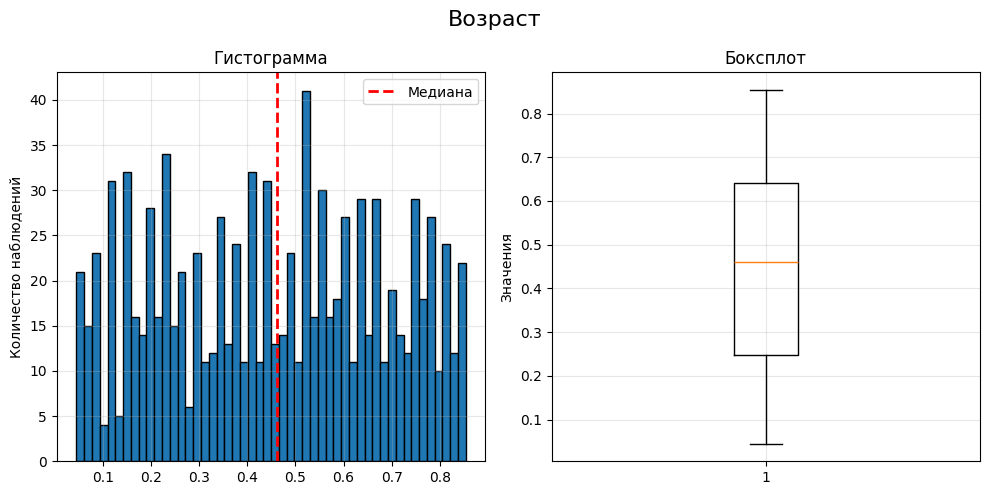

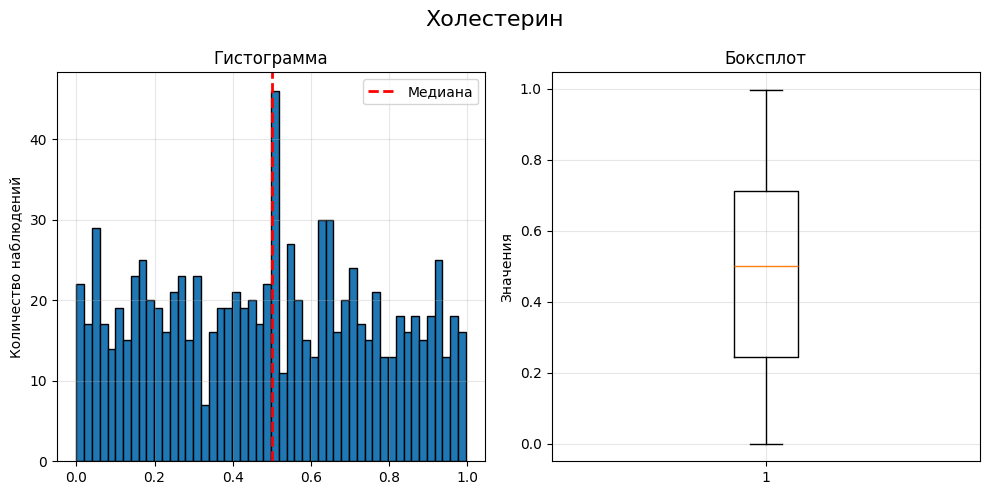

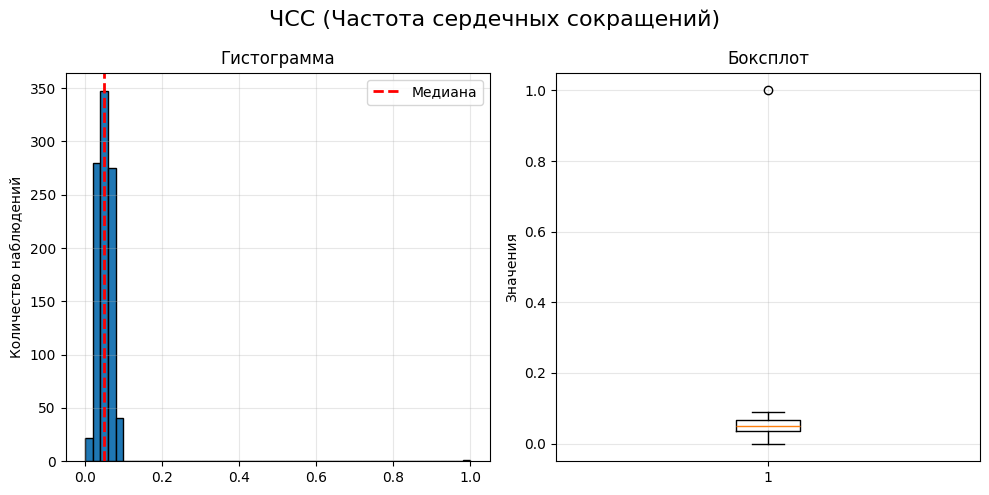

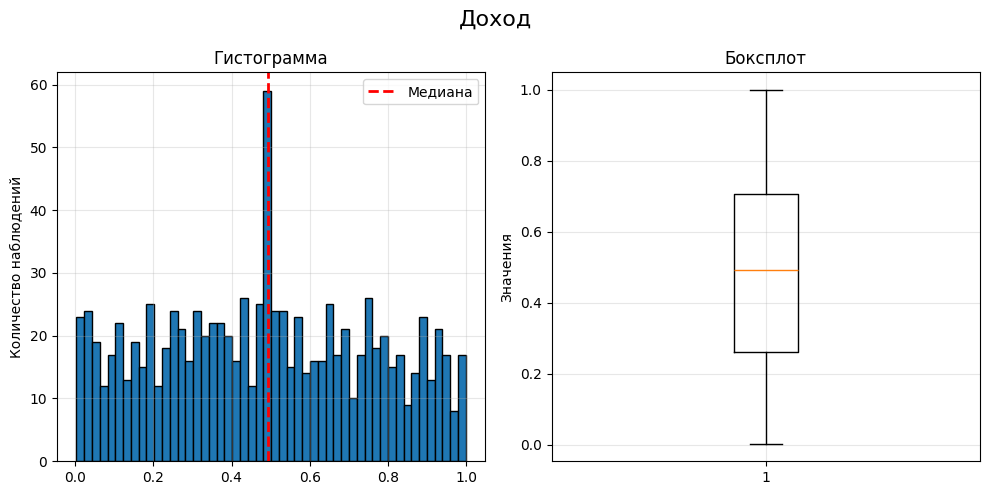

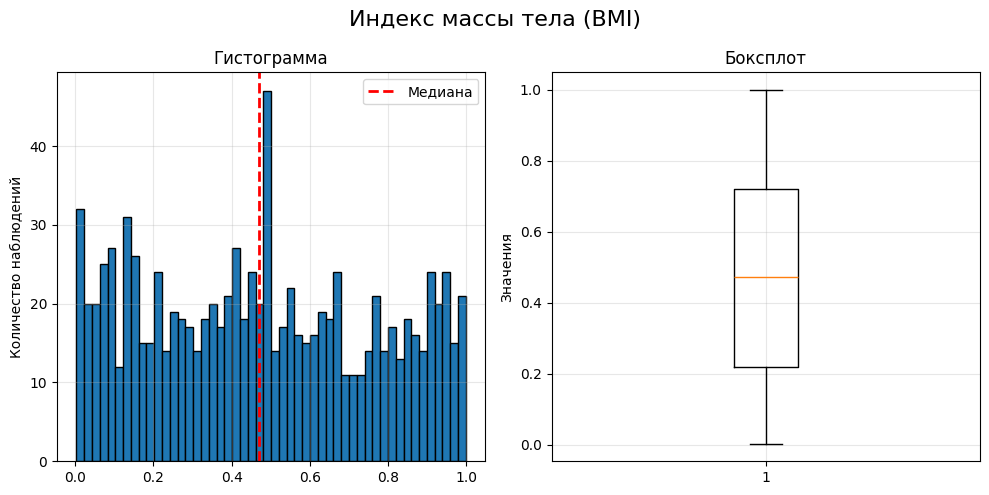

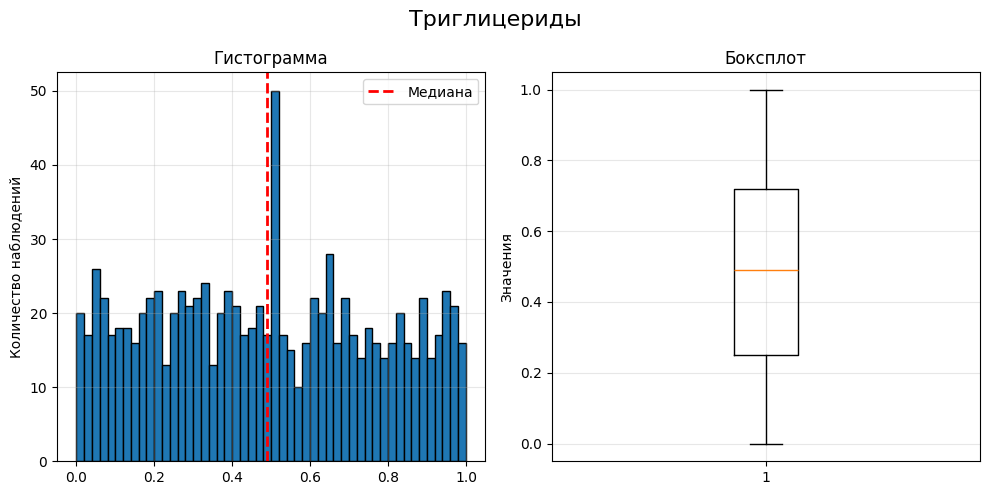

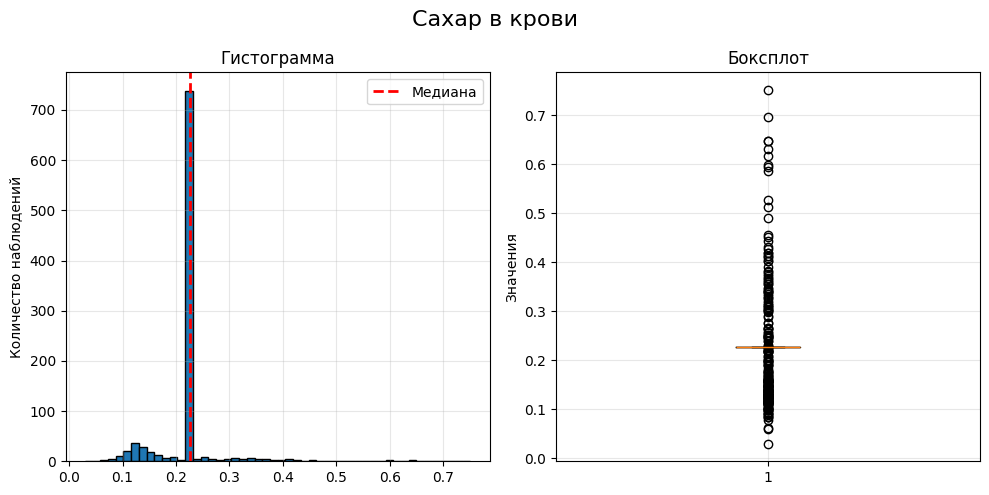

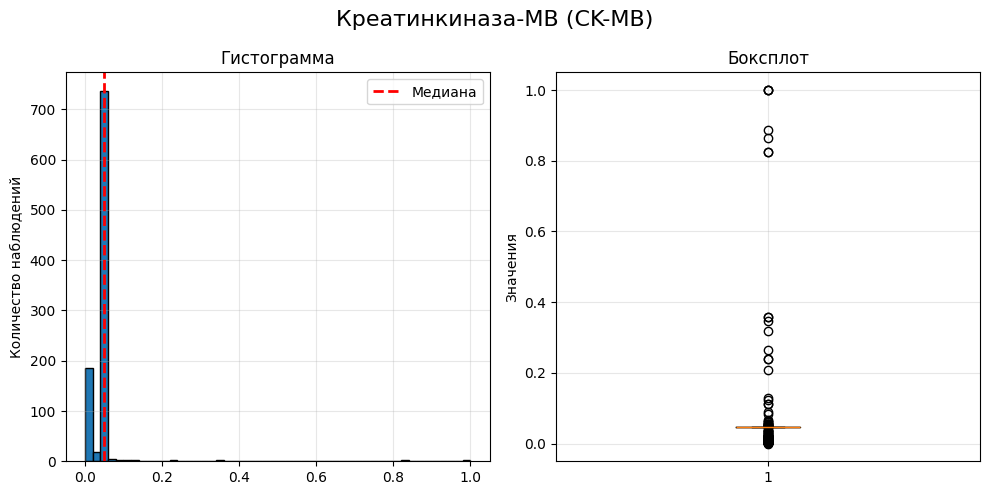

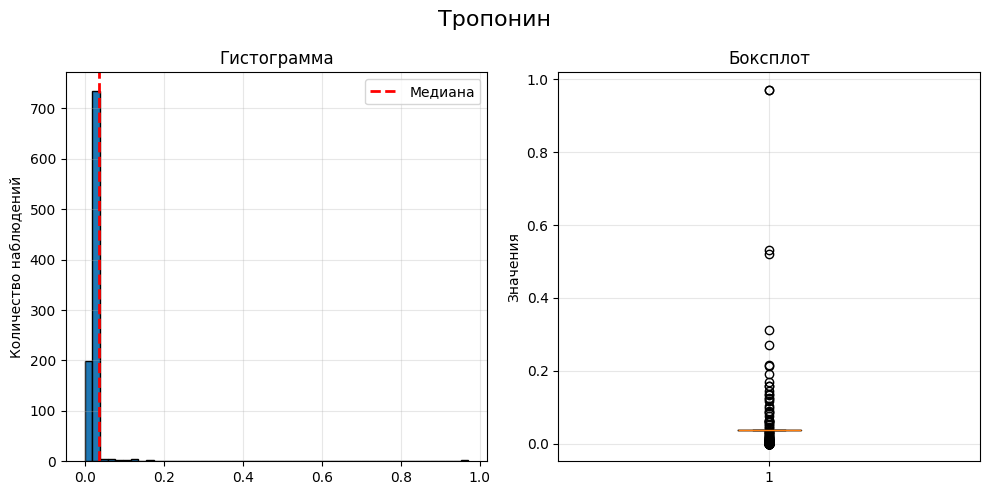

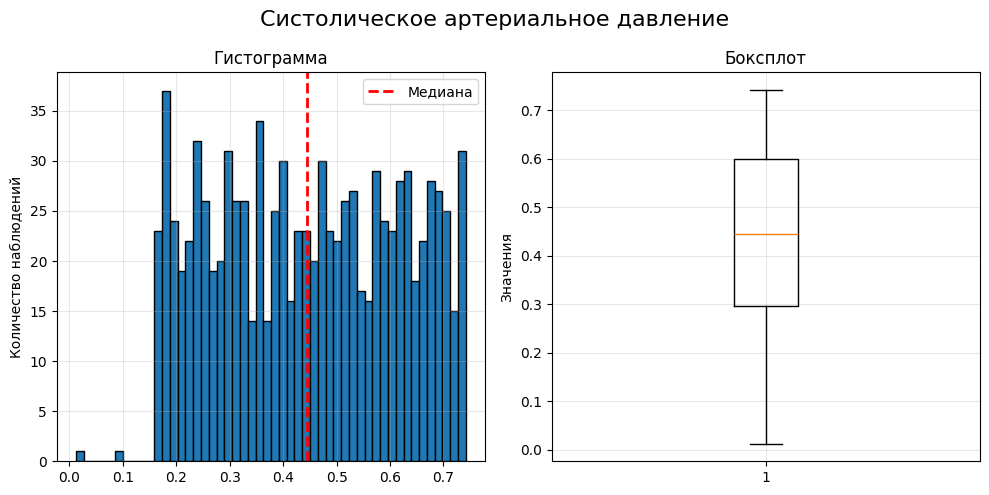

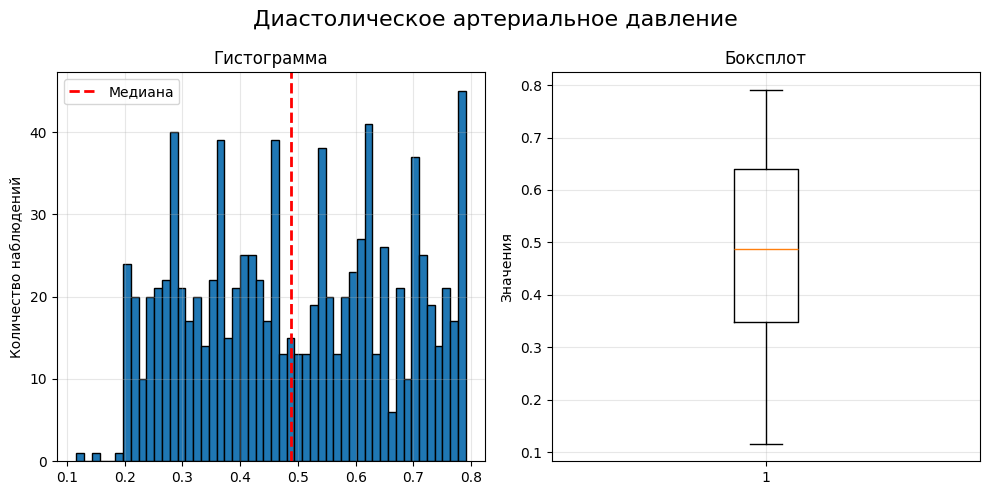

In [17]:
for col in num_list:
    graph(heart_test, col)

Cтатистические выбросы в показателях:
* тропонина, 
* креатинкиназы, 
* сахара, 
* ЧСС
  
 могут отражать патологические состояния, критически важные для прогнозирования риска сердечного приступа. Оставим данные признаки без изменений.

### Матрица корреляции

Создадим функцию для построения матрицы корреляции phik

In [18]:
def phik(df):
    plt.figure(figsize=(16, 12))
    df_part = df.sample(frac=0.2)
    sns.heatmap(df_part.phik_matrix(interval_cols=num_list),
                annot=True, 
                cmap='coolwarm', 
                center=0,
                fmt='.2f',
                square=True,
                cbar_kws={'shrink': 0.8})
    plt.title('Матрица корреляций Phik')
    plt.tight_layout()
    plt.show();

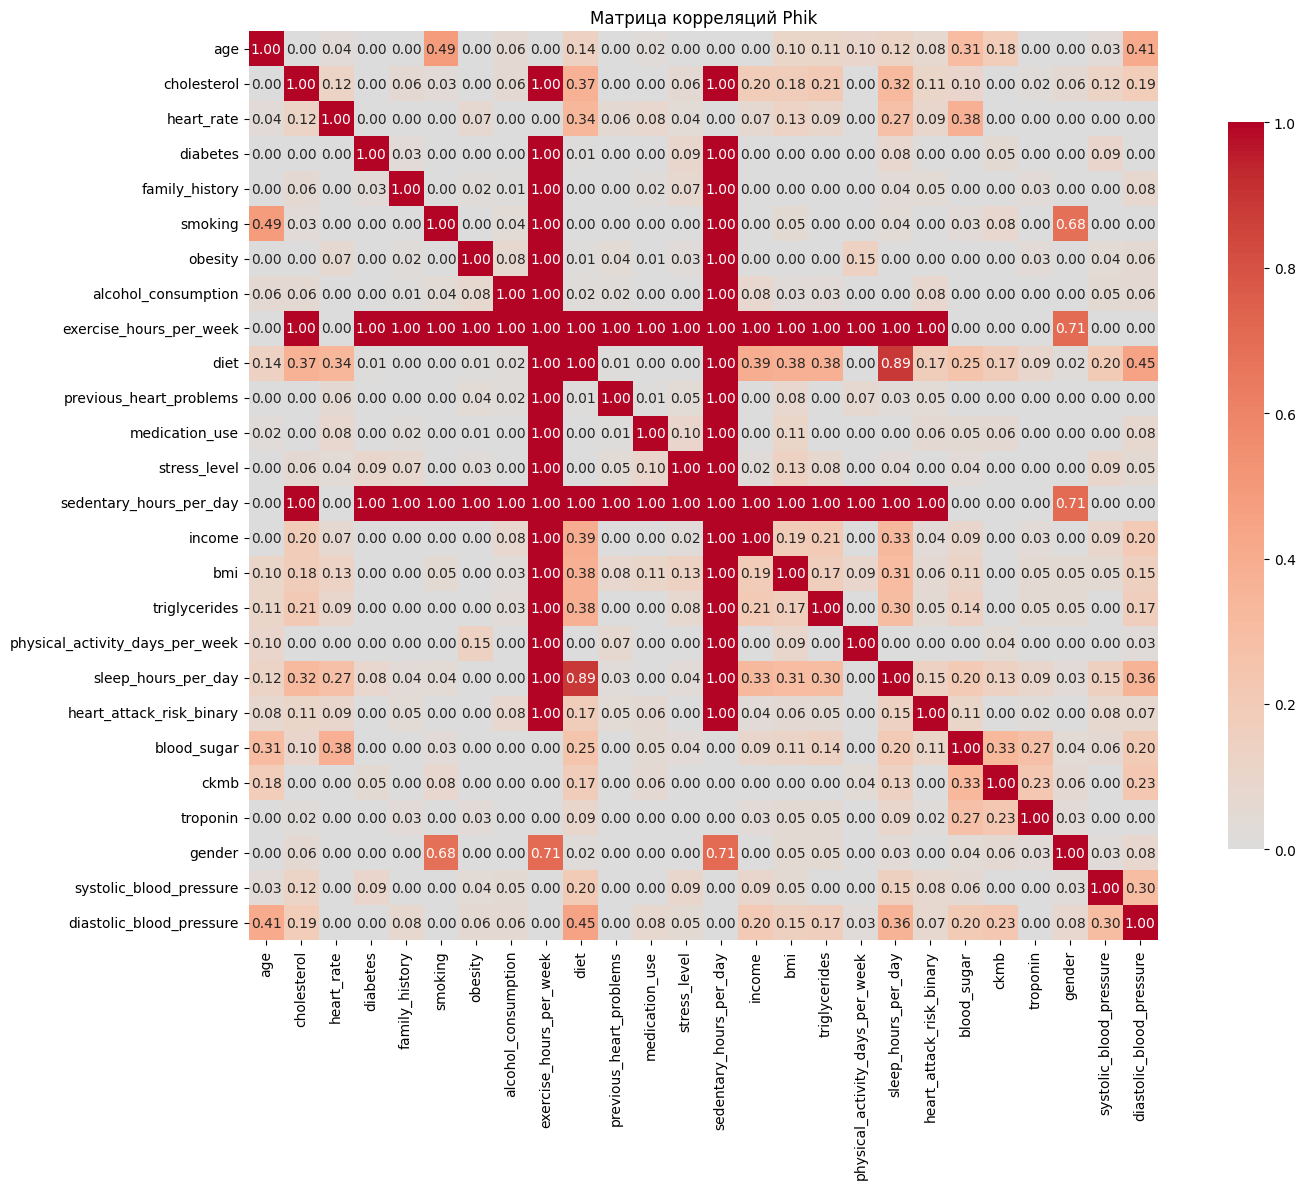

In [19]:
phik(heart_train)

Высока корреляционная связь между признаками:

* sedentary_hours_per_day и некоторыми признаками - 1.00;
* exercise_hours_per_week и некоторыми признаками - 1.00;
* sleep_hours_per_day и diet - 0.89

Наблюдается мультиколлинеарность между признаками, что может негативно сказаться на качестве модели. Поскольку коэффициент корреляции признака sleep_hours_per_day с целевой переменной ниже, чем у признака diet, при построении модели целесообразно исключить sleep_hours_per_day.


### Диаграмма рассеивания

Создадим функцию для построения матрицы диаграммы рассеивания

In [20]:
def matrix(df):
    subset_data = df.sample(frac=0.01)  # Выбираем 1% данных для визуализации
    pd.plotting.scatter_matrix(
        subset_data, 
        figsize=(20, 20), 
        alpha=1, 
        s=50
    )
    plt.tight_layout()
    plt.show()

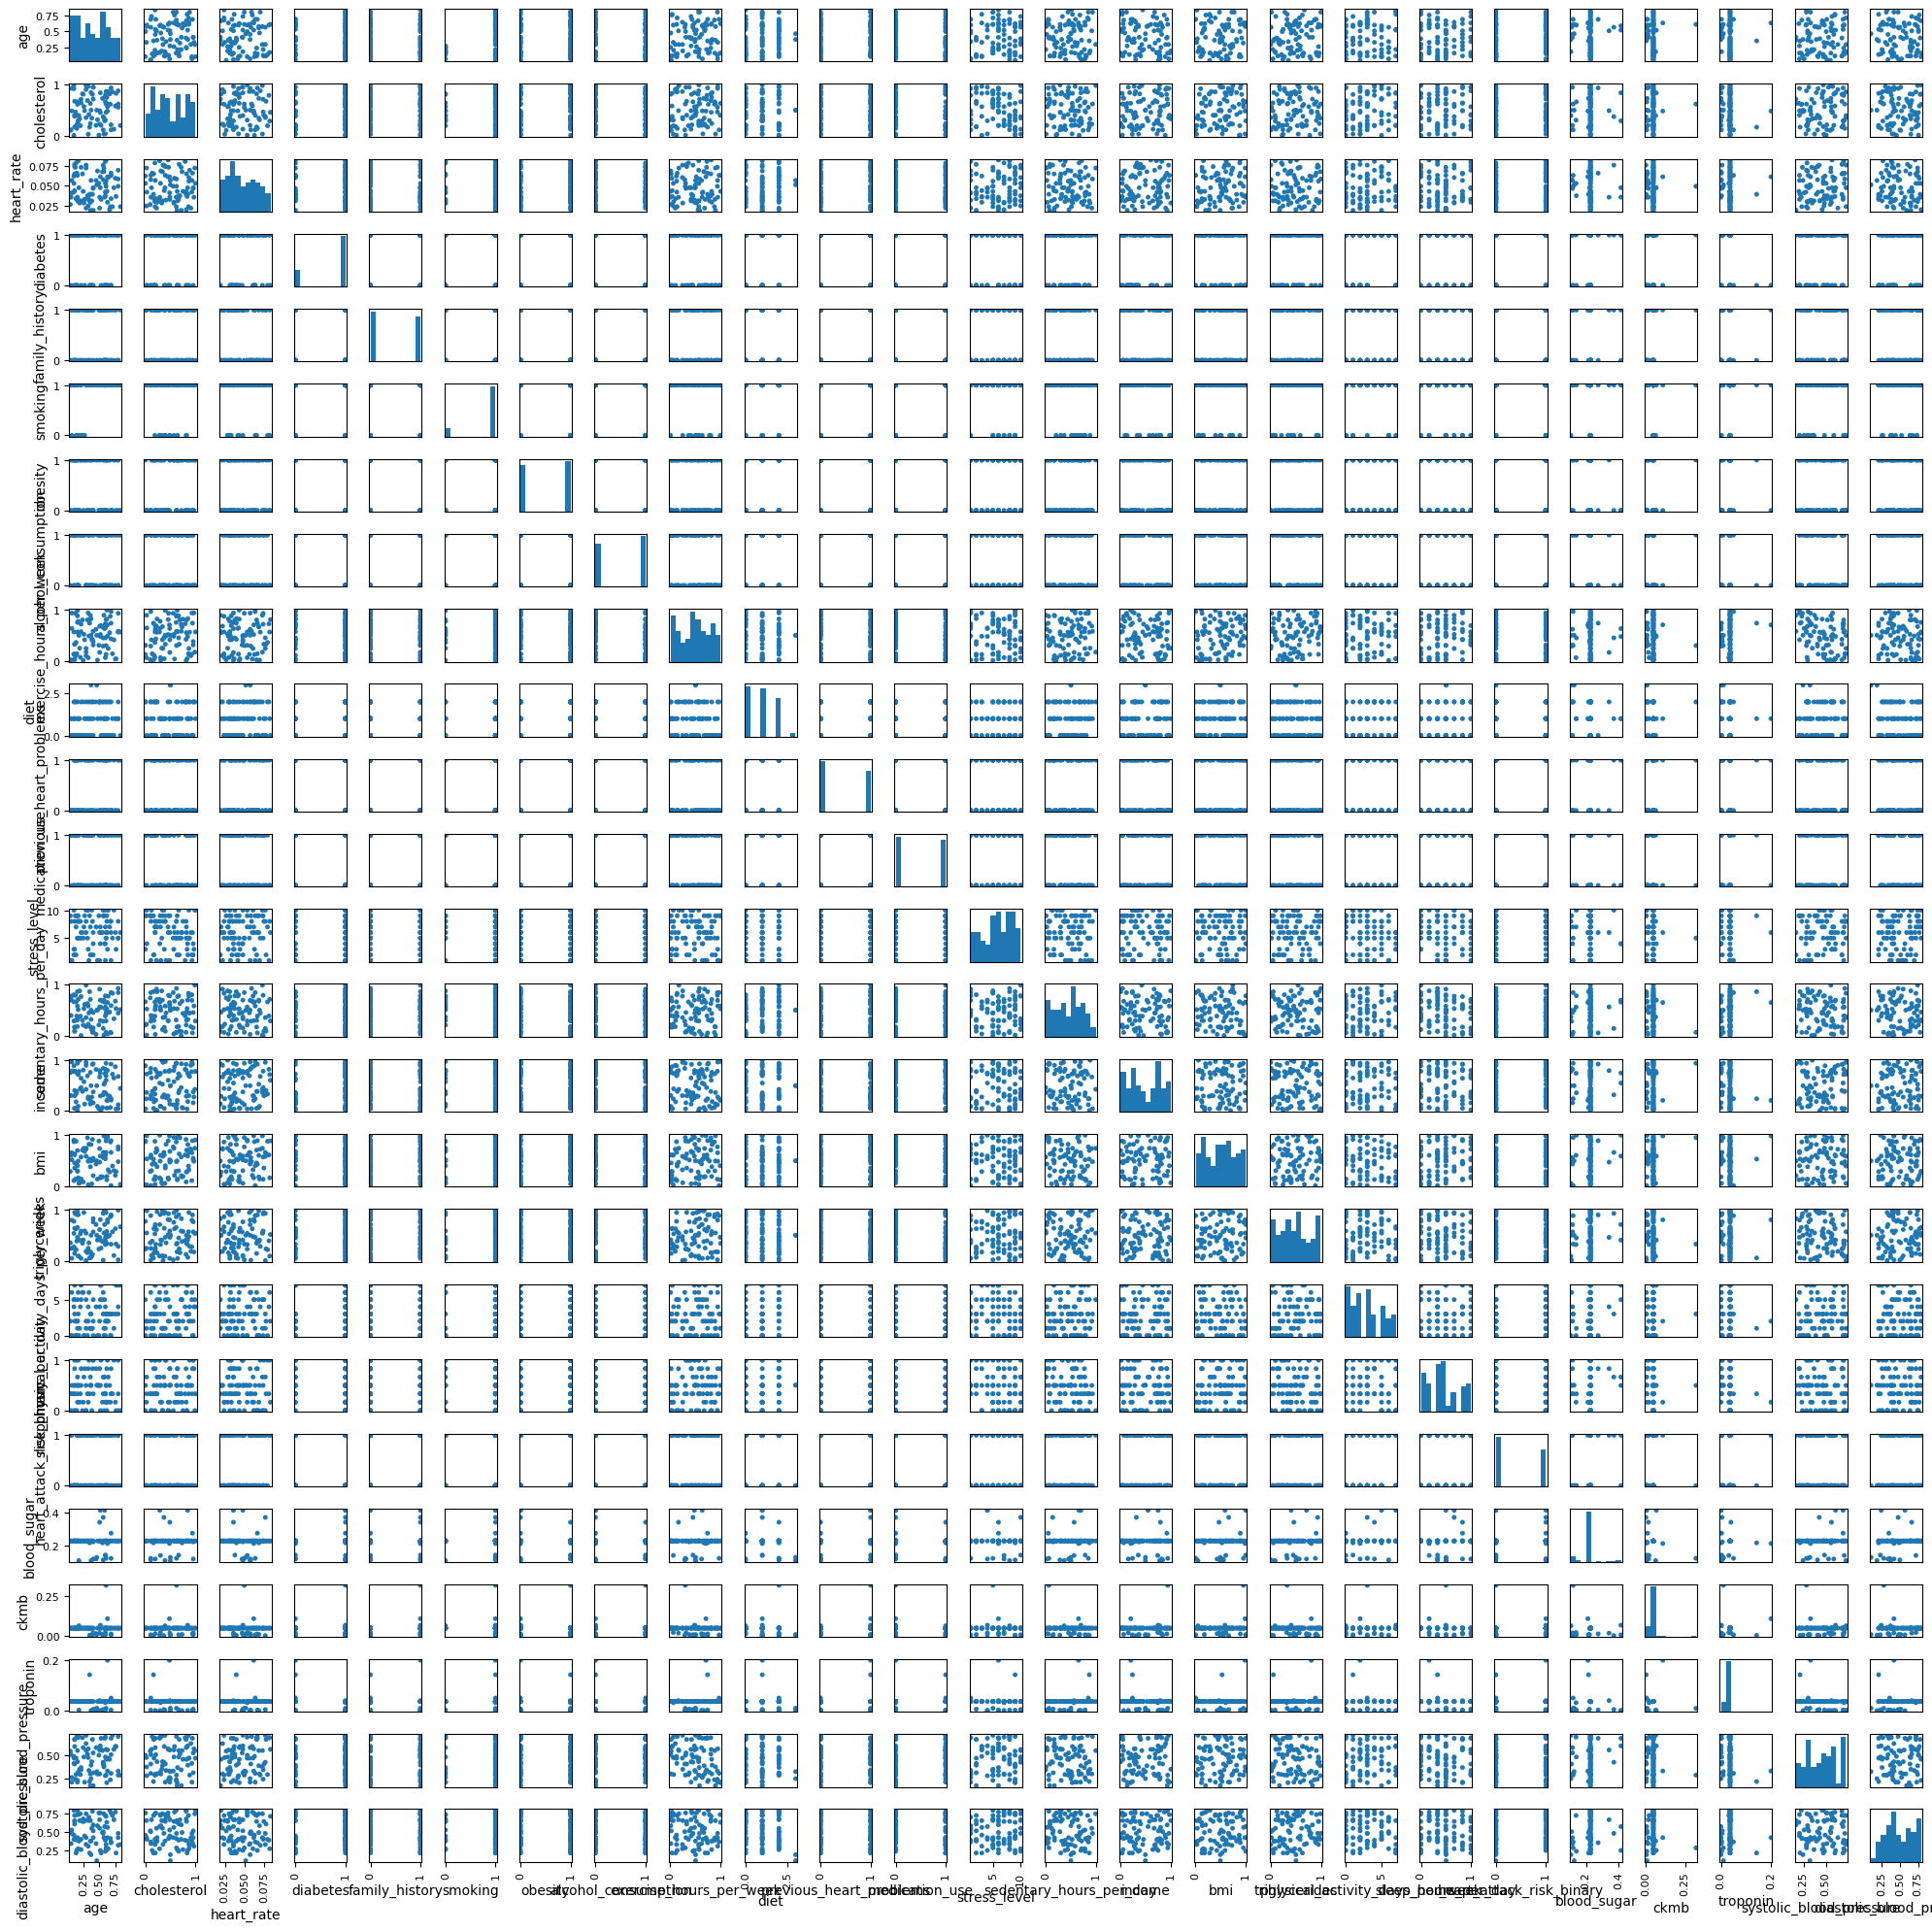

In [21]:
matrix(heart_train)

Матрица корреляции подтверждает выводы сделанные в разделе "Гистограмма и ящик с усами" - есть признаки с выбросами, однако данные выбросы могут иметь важное значение для предсказания таргета.

### Категориальные признаки

Посмотрим на распределение таргета

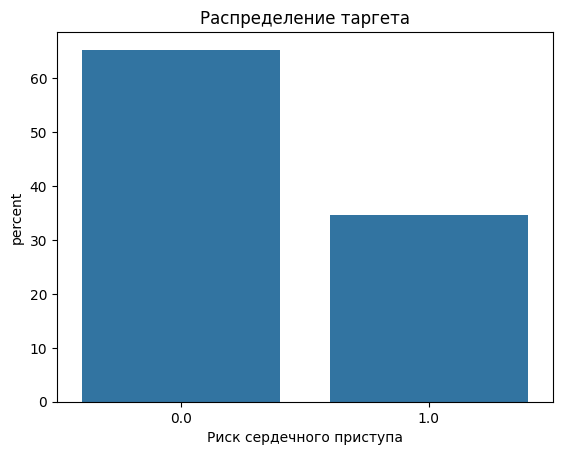

In [22]:
sns.countplot(x='heart_attack_risk_binary', data=heart_train, stat='percent')
plt.title('Распределение таргета')
plt.xlabel('Риск сердечного приступа');

Дисбаланса классов не неблюдаем

Посмотрим на распределения таргета по признакам

In [23]:
cat_list_label = {
       'diabetes' : 'Наличие диабета', 
       'family_history' :'Наличие сердечно-сосудистых заболеваний у родственников',
       'smoking' : 'Курит ли пациент', 
       'obesity' : 'Ниличие ожирения',
       'alcohol_consumption': 'Потребление алкоголя',
       'diet' : 'Диета', 
       'previous_heart_problems' : 'Проблемы с сердцем',
       'medication_use' : 'Использует ли медикаменты', 
       'stress_level' : 'Уровень стресса',
       'physical_activity_days_per_week' : 'Количество дней физической активности в неделю',
       'gender' : 'Пол',
       }

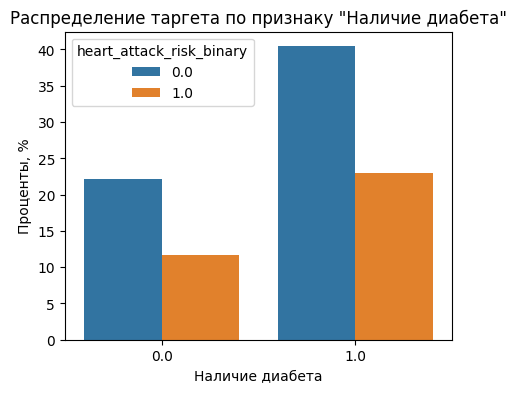

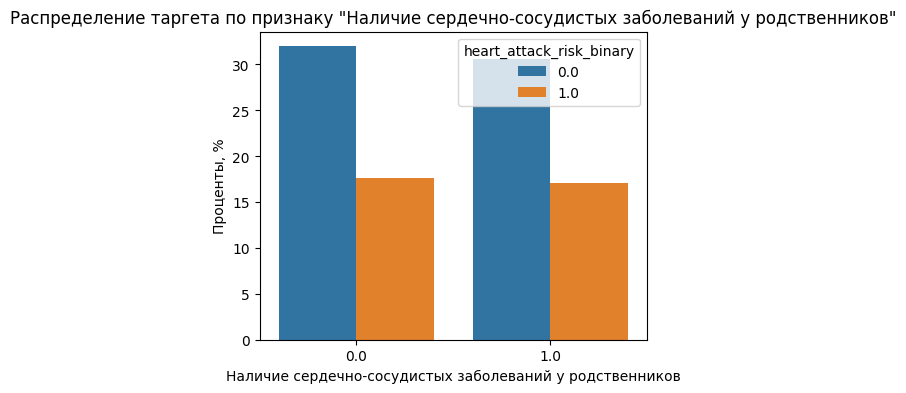

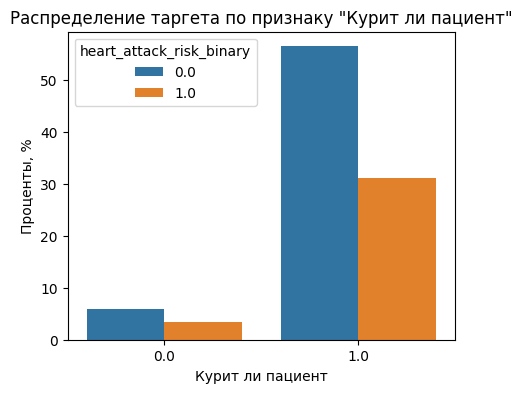

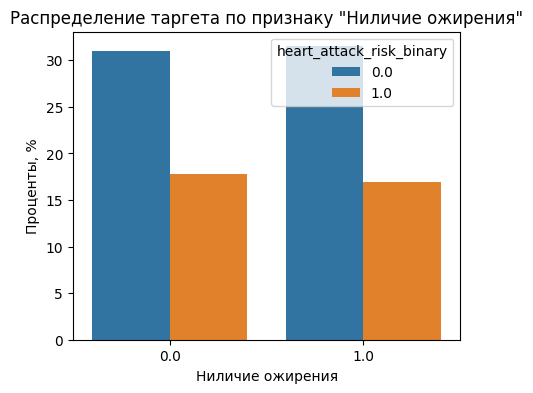

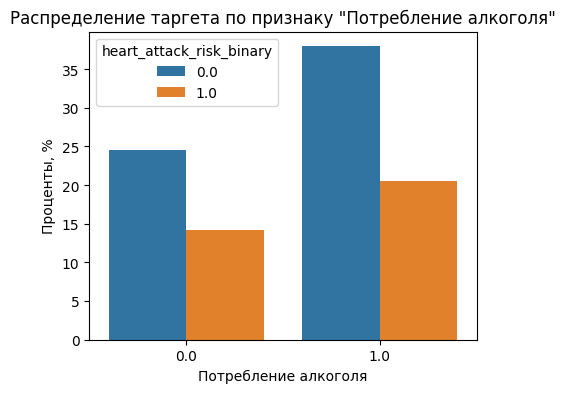

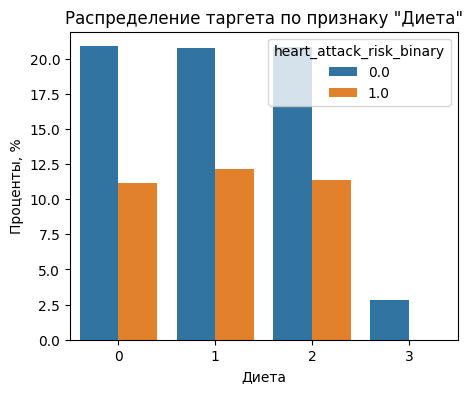

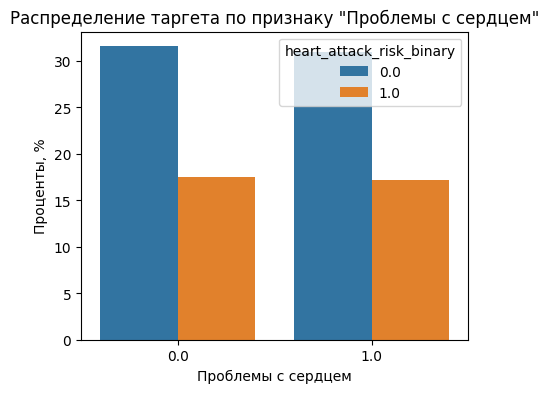

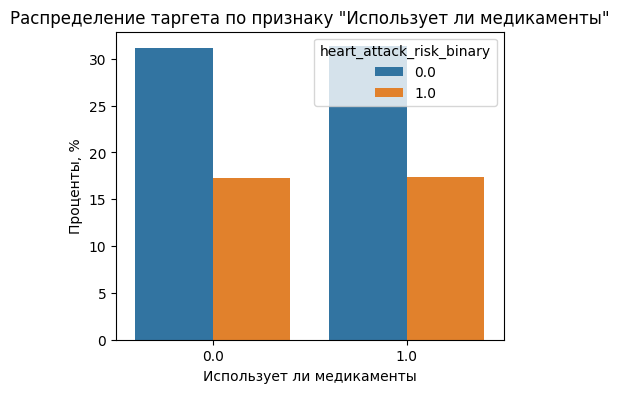

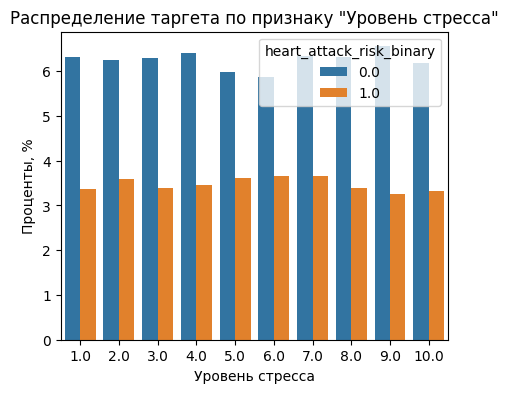

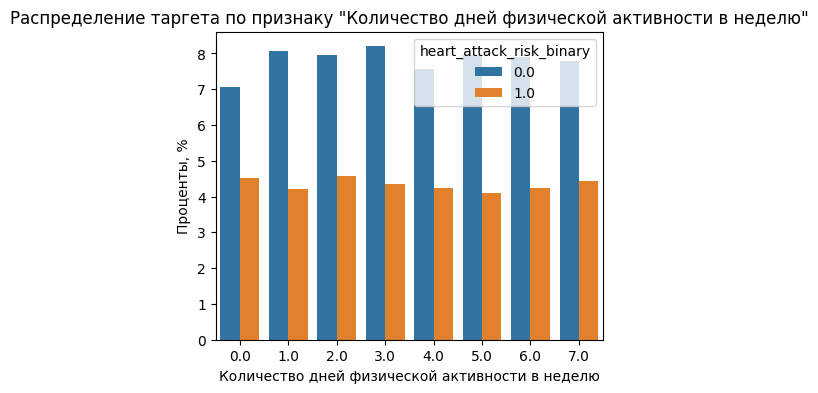

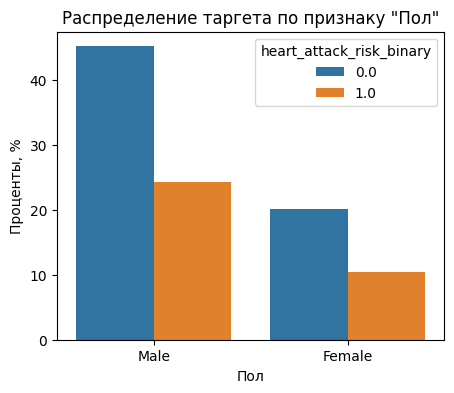

In [24]:
def plot_distribution(df, column):

    plt.figure(figsize=(5,4))
    sns.countplot(x=column, hue='heart_attack_risk_binary', data=heart_train, stat='percent')
    plt.title(f'Распределение таргета по признаку "{cat_list_label.get(column)}"')
    plt.xlabel(cat_list_label.get(column))
    plt.ylabel('Проценты, %')
    plt.show()

for col in cat_list:
    plot_distribution(heart_train, col)

Графика для разных признаков выглядят одинаково, следовательно они являются мало важными для таргета

# МОДЕЛИРОВАНИЕ

## Подготовка данных

Для обучение модели будем использовать алгоритм CatBoost. 

CatBoost выделяется среди других алгоритмов бустинга способностью эффективно работать с категориальными данными и предоставлять точные предсказания, минимизируя риск переобучения и обеспечивая высокую скорость обучения. Алгоритм автоматически обрабатывает пропущенные значения, что уменьшает вероятность возникновения ошибок, связанных с отсутствием данных.

In [25]:
# Начинаем обучение
# Сначали сплиттим выборку

X = heart_train.drop('heart_attack_risk_binary', axis=1)
y = heart_train['heart_attack_risk_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y 
)

# Проверка размерности данных до разбиения данных на выборки
print("\nРазмер данных до разбиения:")
print(f"heart_train shape: {heart_train.shape}")

# Проверка размерности данных после разбиения данных на выборки
print("\nРазмер данных после разбиения:")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Проверяем распределение классов ДО разделения
print("\nРаспределение классов в исходных данных:")
print(heart_train['heart_attack_risk_binary'].value_counts(normalize=True) * 100)

# Проверяем, что стратификация сработала
print("\nРаспределение в обучающей выборке:")
print(y_train.value_counts(normalize=True) * 100)

print("\nРаспределение в тестовой выборке:")
print(y_test.value_counts(normalize=True) * 100)


Размер данных до разбиения:
heart_train shape: (8685, 26)

Размер данных после разбиения:
X_train shape: (6513, 25), X_test shape: (2172, 25)

Распределение классов в исходных данных:
heart_attack_risk_binary
0.0    65.308002
1.0    34.691998
Name: proportion, dtype: float64

Распределение в обучающей выборке:
heart_attack_risk_binary
0.0    65.315523
1.0    34.684477
Name: proportion, dtype: float64

Распределение в тестовой выборке:
heart_attack_risk_binary
0.0    65.285451
1.0    34.714549
Name: proportion, dtype: float64


In [26]:
# Убираем признаки с мультиколлинеарностью

cols_to_remove = ['sedentary_hours_per_day', 'exercise_hours_per_week', 'sleep_hours_per_day']

X_train_clean = X_train.drop(columns=cols_to_remove)
X_test_clean = X_test.drop(columns=cols_to_remove)
heart_test_clean = heart_test.drop(columns=cols_to_remove)

In [27]:
X_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6513 entries, 6242 to 5815
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              6513 non-null   float64
 1   cholesterol                      6513 non-null   float64
 2   heart_rate                       6513 non-null   float64
 3   diabetes                         6318 non-null   float64
 4   family_history                   6318 non-null   float64
 5   smoking                          6318 non-null   float64
 6   obesity                          6318 non-null   float64
 7   alcohol_consumption              6318 non-null   float64
 8   diet                             6513 non-null   int64  
 9   previous_heart_problems          6318 non-null   float64
 10  medication_use                   6318 non-null   float64
 11  stress_level                     6318 non-null   float64
 12  income                

## Моделирование

In [28]:
# Выбираем категориальные признаки
cat_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()

# Задаем усредненные гиперпараметры
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50
)

# Теперь обучаем модель
model.fit(
    X_train_clean, y_train,
    cat_features=cat_features,
    verbose=0
);

In [29]:
# Оценим качество
y_pred = model.predict(X_test_clean)
acc = accuracy_score(y_test, y_pred)
print(f"Доля правильный ответов: {acc*100:.2f} %")

Доля правильный ответов: 63.72 %


In [30]:
# Предсказание на тесте
predictions = model.predict(heart_test_clean)

# Создаем DataFrame с предсказаниями и идентификаторами
df = pd.DataFrame({'prediction': predictions}, index=heart_test.index)

# Сохраняем DataFrame в CSV-файл
df.to_csv('predictions.csv', index=True) 

df.value_counts()

prediction
0.0           841
1.0           125
Name: count, dtype: int64

In [31]:
# Сохраняем обученную модель ввиде файла

joblib.dump(model, "model.pkl")

['model.pkl']

## Вывод

Для машинного обучения использована модель CatBoost с гиперпараметрами:
* iterations=1000,
* learning_rate=0.05,
* depth=6,
* eval_metric='Accuracy',
* random_seed=RANDOM_STATE,
* early_stopping_rounds=50

Для оценки точности предсказания модели использована стандартная метрика Accuracy.

# ВЫВОД

Создана модель машинного обучения, которая на основе представленной характеристики пациента предсказывает риска сердечного приступа  — высокий или низкий.